# Análise Intermediária de Contratos Públicos de Recife

Este notebook apresenta análises avançadas dos contratos públicos de Recife, incluindo:
- Análise de relacionamentos e redes
- Análise geográfica
- Análise textual e categorização

## Pré-requisitos

Execute primeiro o notebook `pe_recife.ipynb` para gerar o dataset limpo.

## 1. Configuração Inicial e Importação de Bibliotecas

In [32]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
from collections import Counter
import re

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para análise de redes
import networkx as nx
from networkx.algorithms import bipartite

# Bibliotecas para análise textual
from wordcloud import WordCloud
import unicodedata

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Configurações do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Suprimir avisos
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [33]:
# Carregar dados limpos
data_path = '../../../data/pe/recife/dados_abertos_contratos.csv'
df = pd.read_csv(data_path, sep=';', encoding='utf-8', low_memory=False)

# Preparação básica
df['datainiciovigencia'] = pd.to_datetime(df['datainiciovigencia'], format='%Y/%m/%d %H:%M:%S.%f', errors='coerce')
df['datafimvigencia'] = pd.to_datetime(df['datafimvigencia'], format='%Y/%m/%d %H:%M:%S.%f', errors='coerce')
df['valorcontrato1'] = pd.to_numeric(df['valorcontrato1'], errors='coerce')
df['valorcontrato2'] = pd.to_numeric(df['valorcontrato2'], errors='coerce')

print(f"Dataset carregado: {len(df):,} contratos")
print(f"Período: {df['anocontrato'].min()} a {df['anocontrato'].max()}")

Dataset carregado: 8,202 contratos
Período: 2004.0 a 2026.0


---

# PARTE 1: ANÁLISE DE RELACIONAMENTOS E REDES

## 3. Análise de Relacionamentos: Fornecedores vs Órgãos

Vamos mapear a rede de relacionamentos entre fornecedores e órgãos contratantes para identificar padrões de concentração e diversificação.

### 3.1 Diversificação de Fornecedores

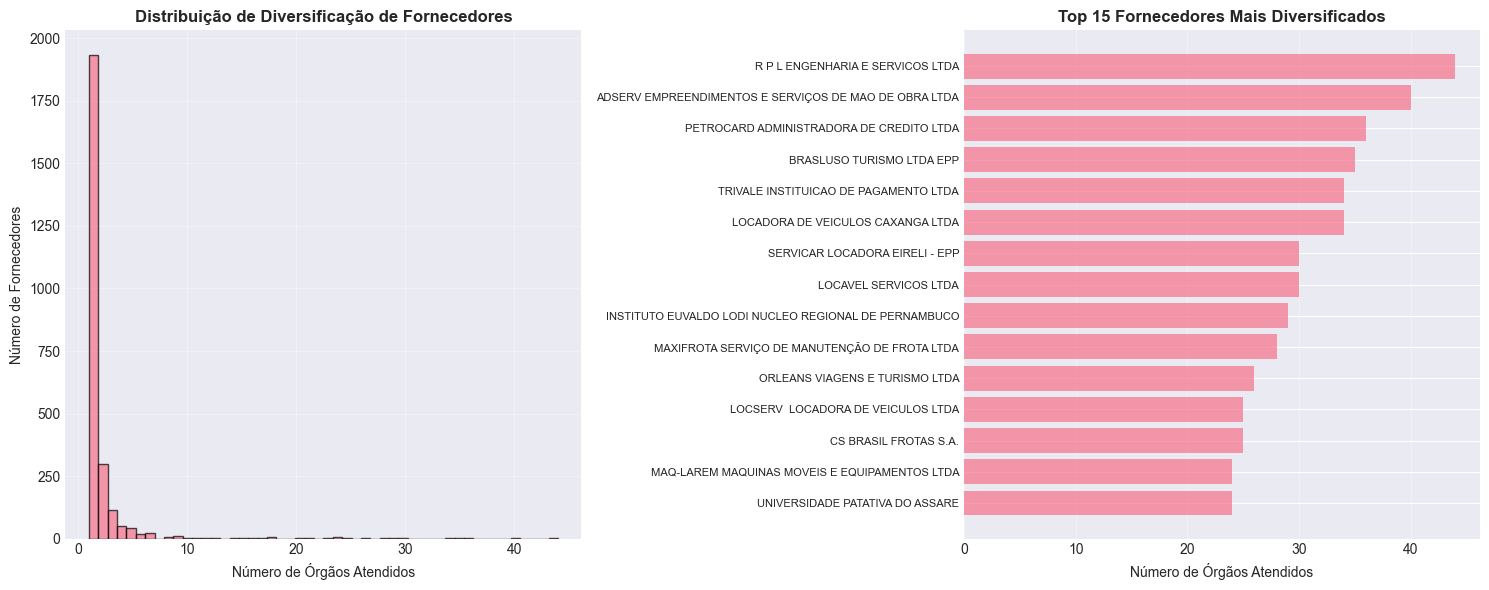

In [34]:
# Analisar quantos órgãos diferentes cada fornecedor atende
supplier_agencies = df.groupby('razaonomecontratado').agg({
    'orgaocontratante': lambda x: x.nunique(),
    'numerocontrato': 'count',
    'valorcontrato1': 'sum'
}).rename(columns={
    'orgaocontratante': 'num_orgaos',
    'numerocontrato': 'num_contratos',
    'valorcontrato1': 'valor_total'
}).sort_values('num_orgaos', ascending=False)

print("DIVERSIFICAÇÃO DE FORNECEDORES")
print("=" * 80)
print(f"\nFornecedores que atendem múltiplos órgãos:")
print(f"  - 1 órgão: {(supplier_agencies['num_orgaos'] == 1).sum():,} fornecedores")
print(f"  - 2-5 órgãos: {((supplier_agencies['num_orgaos'] >= 2) & (supplier_agencies['num_orgaos'] <= 5)).sum():,} fornecedores")
print(f"  - 6-10 órgãos: {((supplier_agencies['num_orgaos'] >= 6) & (supplier_agencies['num_orgaos'] <= 10)).sum():,} fornecedores")
print(f"  - Mais de 10 órgãos: {(supplier_agencies['num_orgaos'] > 10).sum():,} fornecedores")

print(f"\nTop 20 fornecedores mais diversificados:")
display(supplier_agencies.head(20))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribuição de diversificação
axes[0].hist(supplier_agencies['num_orgaos'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Número de Órgãos Atendidos')
axes[0].set_ylabel('Número de Fornecedores')
axes[0].set_title('Distribuição de Diversificação de Fornecedores', fontweight='bold')
axes[0].grid(alpha=0.3)

# Top 15 mais diversificados
top_diversified = supplier_agencies.head(15)
axes[1].barh(range(len(top_diversified)), top_diversified['num_orgaos'], alpha=0.7)
axes[1].set_yticks(range(len(top_diversified)))
axes[1].set_yticklabels(top_diversified.index, fontsize=8)
axes[1].set_xlabel('Número de Órgãos Atendidos')
axes[1].set_title('Top 15 Fornecedores Mais Diversificados', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 3.2 Rede Bipartida: Fornecedores e Órgãos

Criamos uma rede bipartida onde fornecedores se conectam aos órgãos com os quais possuem contratos.

In [35]:
# Criar rede bipartida
G = nx.Graph()

# Filtrar top fornecedores e órgãos para visualização (rede muito grande fica ilegível)
top_suppliers = df.groupby('razaonomecontratado')['valorcontrato1'].sum().nlargest(30).index
top_agencies = df.groupby('orgaocontratante')['valorcontrato1'].sum().nlargest(15).index

df_network = df[
    (df['razaonomecontratado'].isin(top_suppliers)) & 
    (df['orgaocontratante'].isin(top_agencies))
]

# Adicionar nós e arestas
for _, row in df_network.iterrows():
    supplier = row['razaonomecontratado']
    agency = row['orgaocontratante']
    value = row['valorcontrato1']
    
    G.add_node(supplier, bipartite=0, node_type='Fornecedor')
    G.add_node(agency, bipartite=1, node_type='Órgão')
    
    if G.has_edge(supplier, agency):
        G[supplier][agency]['weight'] += value
        G[supplier][agency]['num_contracts'] += 1
    else:
        G.add_edge(supplier, agency, weight=value, num_contracts=1)

print("ESTATÍSTICAS DA REDE BIPARTIDA")
print("=" * 80)
print(f"Número de nós (fornecedores + órgãos): {G.number_of_nodes()}")
print(f"Número de arestas (relacionamentos): {G.number_of_edges()}")
print(f"Densidade da rede: {nx.density(G):.4f}")

# Separar nós por tipo
suppliers_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'Fornecedor']
agencies_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'Órgão']

print(f"\nNós fornecedores: {len(suppliers_nodes)}")
print(f"Nós órgãos: {len(agencies_nodes)}")

ESTATÍSTICAS DA REDE BIPARTIDA
Número de nós (fornecedores + órgãos): 45
Número de arestas (relacionamentos): 94
Densidade da rede: 0.0949

Nós fornecedores: 30
Nós órgãos: 15


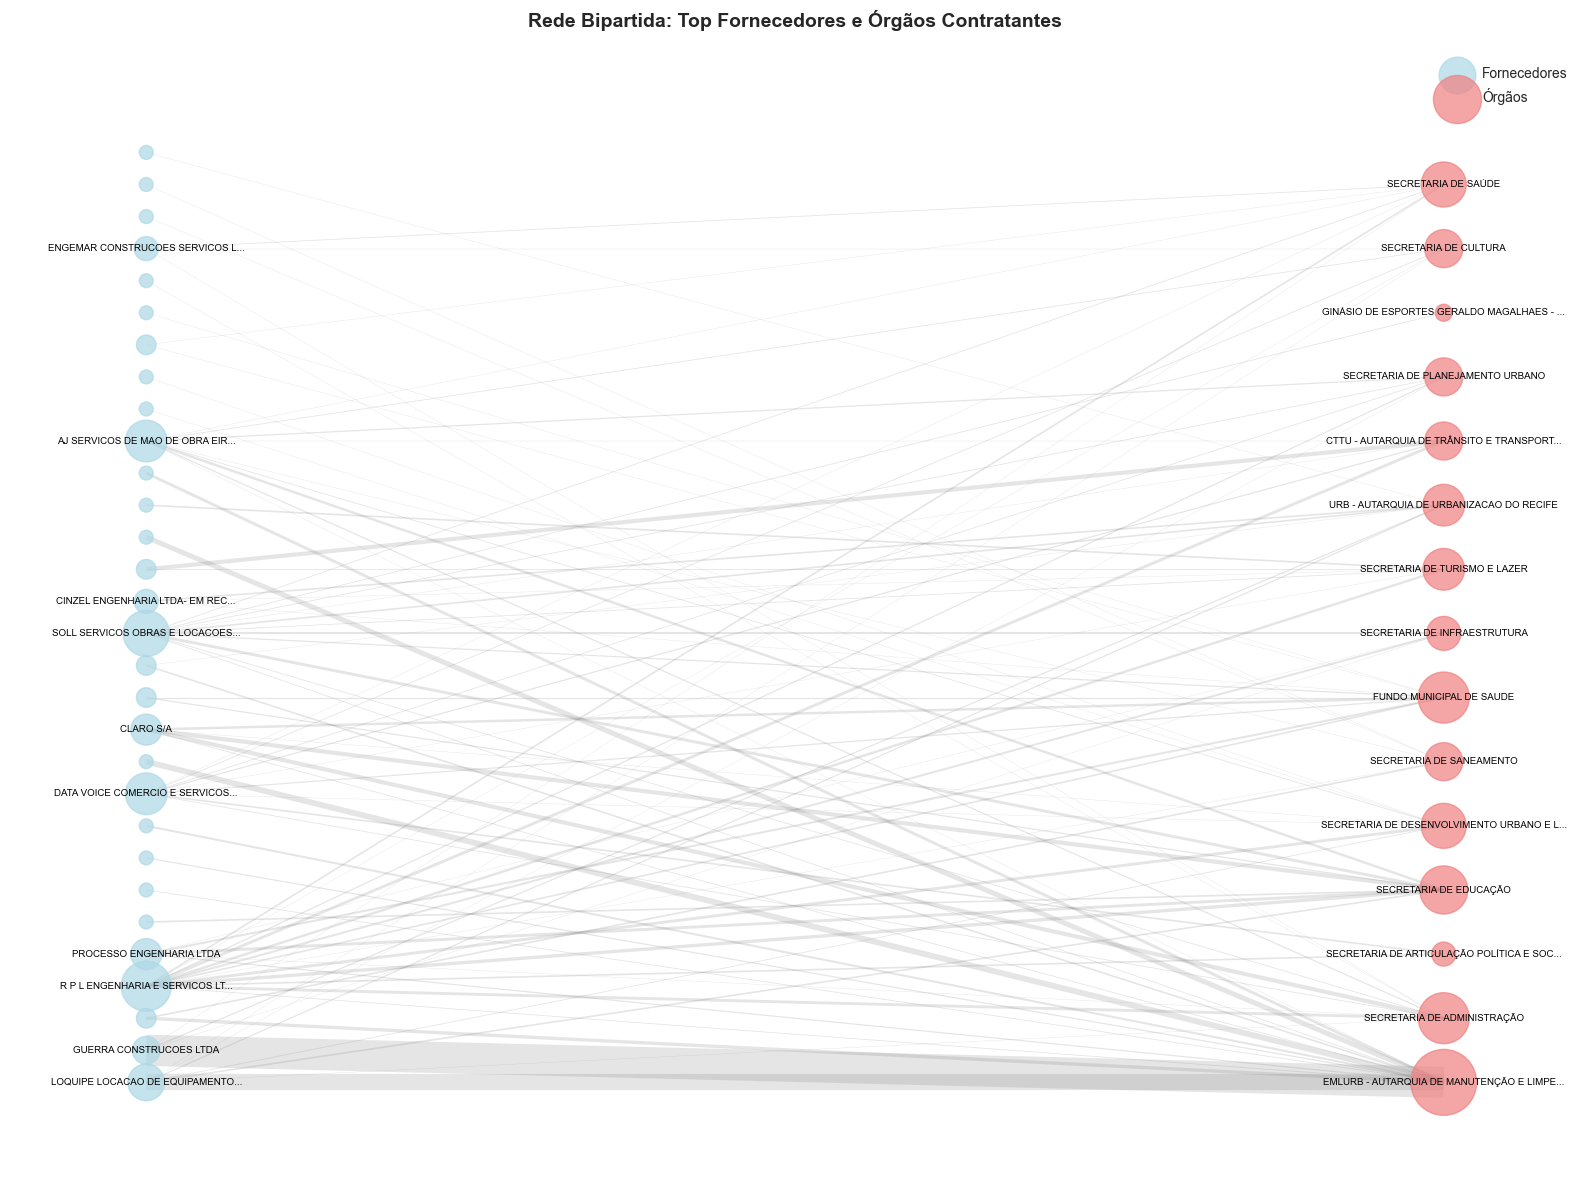

In [36]:
# Visualização da rede bipartida
fig, ax = plt.subplots(figsize=(16, 12))

# Layout bipartido
pos = {}
suppliers_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'Fornecedor']
agencies_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'Órgão']

# Posicionar fornecedores à esquerda
for i, supplier in enumerate(suppliers_nodes):
    pos[supplier] = (0, i)

# Posicionar órgãos à direita
for i, agency in enumerate(agencies_nodes):
    pos[agency] = (2, i * len(suppliers_nodes) / len(agencies_nodes))

# Tamanho dos nós baseado no grau
node_sizes_suppliers = [G.degree(n) * 100 for n in suppliers_nodes]
node_sizes_agencies = [G.degree(n) * 150 for n in agencies_nodes]

# Desenhar nós
nx.draw_networkx_nodes(G, pos, nodelist=suppliers_nodes, 
                       node_color='lightblue', node_size=node_sizes_suppliers,
                       alpha=0.7, label='Fornecedores', ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=agencies_nodes, 
                       node_color='lightcoral', node_size=node_sizes_agencies,
                       alpha=0.7, label='Órgãos', ax=ax)

# Desenhar arestas com espessura baseada no número de contratos
edges = G.edges()
weights = [G[u][v]['num_contracts'] for u, v in edges]
nx.draw_networkx_edges(G, pos, width=[w*0.3 for w in weights], 
                       alpha=0.2, edge_color='gray', ax=ax)

# Labels (apenas para alguns nós para não poluir)
top_degree_suppliers = sorted(suppliers_nodes, key=lambda x: G.degree(x), reverse=True)[:10]
labels_suppliers = {n: n[:30] + '...' if len(n) > 30 else n for n in top_degree_suppliers}
labels_agencies = {n: n[:40] + '...' if len(n) > 40 else n for n in agencies_nodes}
labels = {**labels_suppliers, **labels_agencies}

nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)

ax.set_title('Rede Bipartida: Top Fornecedores e Órgãos Contratantes', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

### 3.3 Métricas de Centralidade

Identificamos os atores mais centrais na rede usando diferentes métricas de centralidade.

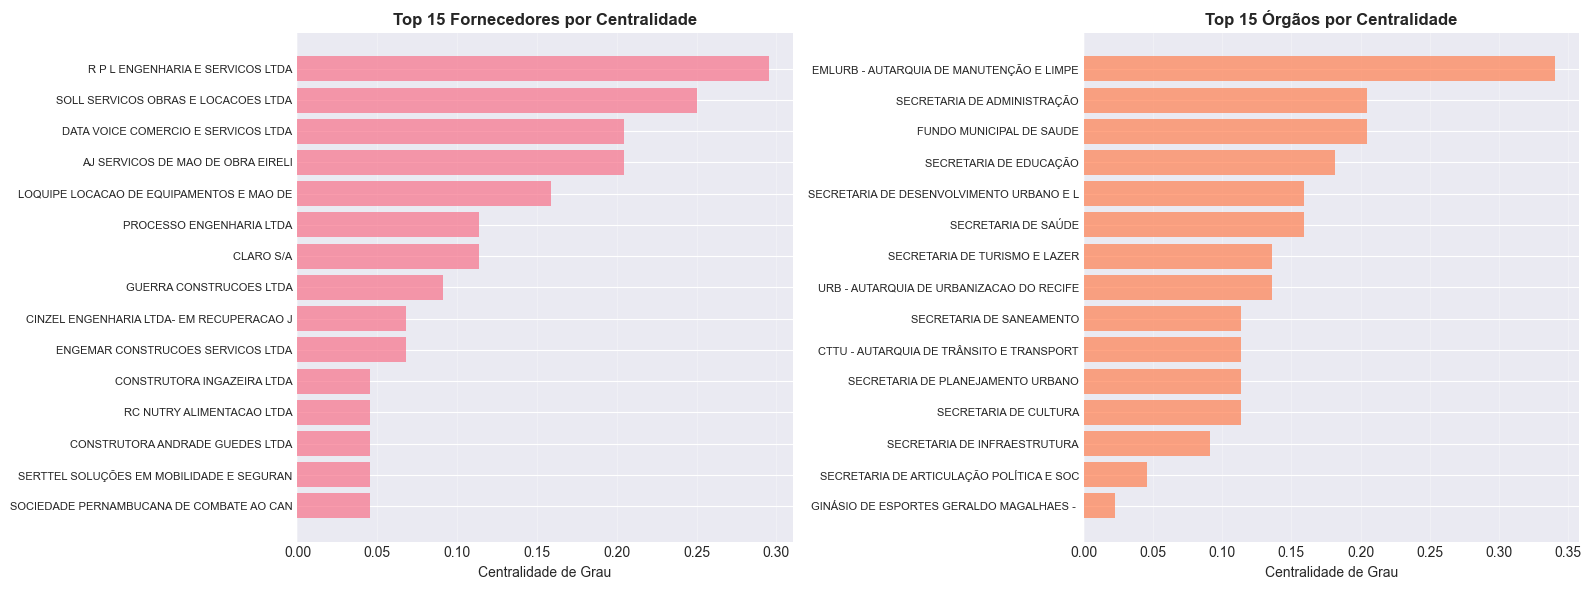

In [37]:
# Calcular métricas de centralidade
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Criar DataFrame com métricas
centrality_df = pd.DataFrame({
    'node': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': list(betweenness_centrality.values()),
    'degree': [G.degree(n) for n in degree_centrality.keys()],
    'tipo': [G.nodes[n]['node_type'] for n in degree_centrality.keys()]
})

print("TOP 15 NÓS POR CENTRALIDADE DE GRAU")
print("=" * 80)
display(centrality_df.nlargest(15, 'degree_centrality')[['node', 'tipo', 'degree', 'degree_centrality']])

print("\nTOP 15 NÓS POR CENTRALIDADE DE INTERMEDIAÇÃO")
print("=" * 80)
display(centrality_df.nlargest(15, 'betweenness_centrality')[['node', 'tipo', 'degree', 'betweenness_centrality']])

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top fornecedores por centralidade
top_suppliers_central = centrality_df[centrality_df['tipo'] == 'Fornecedor'].nlargest(15, 'degree_centrality')
axes[0].barh(range(len(top_suppliers_central)), top_suppliers_central['degree_centrality'], alpha=0.7)
axes[0].set_yticks(range(len(top_suppliers_central)))
axes[0].set_yticklabels([n[:40] for n in top_suppliers_central['node']], fontsize=8)
axes[0].set_xlabel('Centralidade de Grau')
axes[0].set_title('Top 15 Fornecedores por Centralidade', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Top órgãos por centralidade
top_agencies_central = centrality_df[centrality_df['tipo'] == 'Órgão'].nlargest(15, 'degree_centrality')
axes[1].barh(range(len(top_agencies_central)), top_agencies_central['degree_centrality'], 
             alpha=0.7, color='coral')
axes[1].set_yticks(range(len(top_agencies_central)))
axes[1].set_yticklabels([n[:40] for n in top_agencies_central['node']], fontsize=8)
axes[1].set_xlabel('Centralidade de Grau')
axes[1].set_title('Top 15 Órgãos por Centralidade', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 3.4 Análise de Comunidades

Identificamos grupos de fornecedores que tendem a trabalhar com os mesmos órgãos.

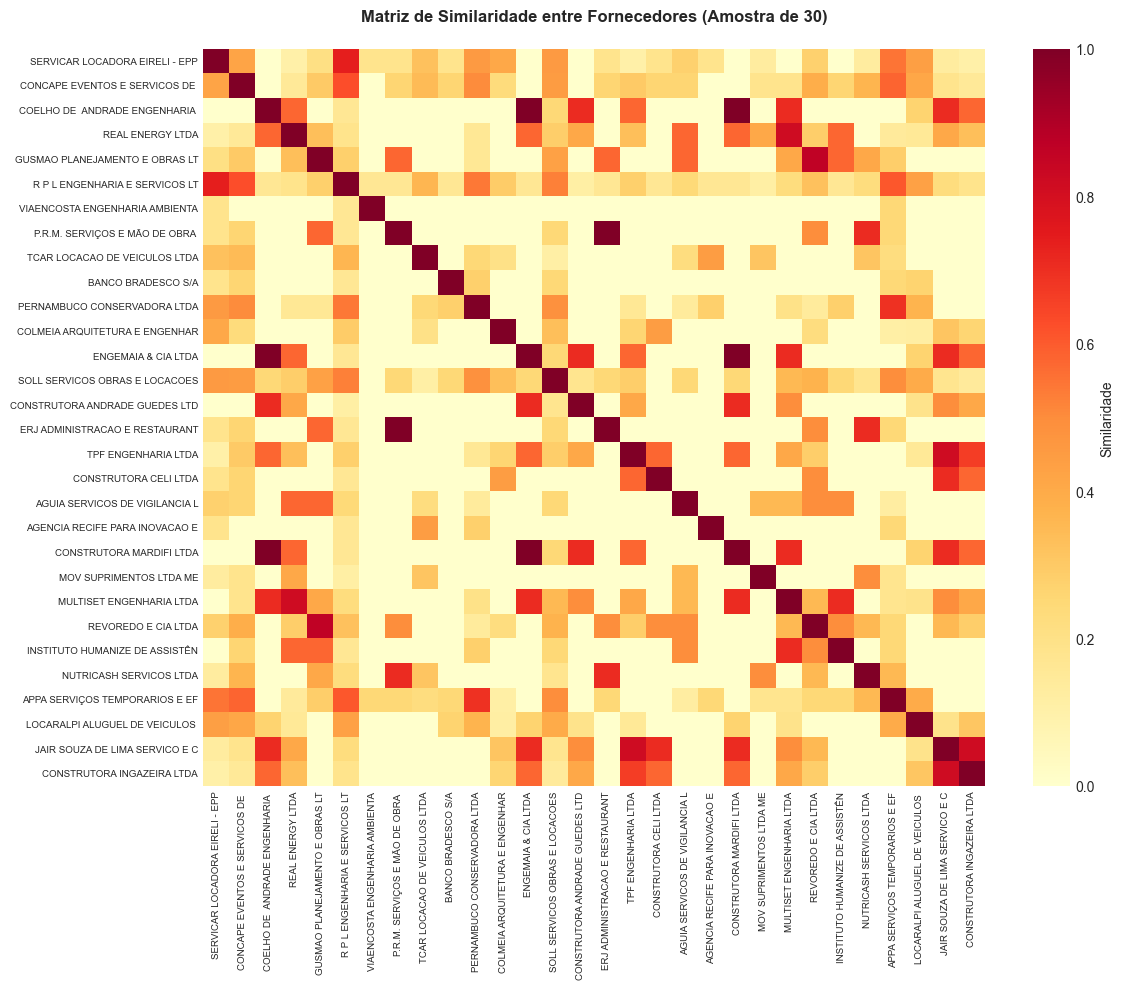

In [38]:
# Criar matriz de similaridade entre fornecedores
# Dois fornecedores são similares se trabalham com os mesmos órgãos

# Criar matriz fornecedor x órgão
supplier_agency_matrix = df.pivot_table(
    index='razaonomecontratado',
    columns='orgaocontratante',
    values='valorcontrato1',
    aggfunc='sum',
    fill_value=0
)

# Binarizar (1 se tem contrato, 0 caso contrário)
supplier_agency_binary = (supplier_agency_matrix > 0).astype(int)

# Calcular similaridade (Jaccard)
from sklearn.metrics.pairwise import cosine_similarity

# Filtrar apenas top fornecedores para análise
top_100_suppliers = df.groupby('razaonomecontratado')['valorcontrato1'].sum().nlargest(100).index
supplier_agency_binary_top = supplier_agency_binary.loc[top_100_suppliers]

similarity_matrix = cosine_similarity(supplier_agency_binary_top)

print("ANÁLISE DE SIMILARIDADE ENTRE FORNECEDORES")
print("=" * 80)
print(f"\nMatriz de similaridade calculada para top {len(top_100_suppliers)} fornecedores")
print(f"Similaridade média: {similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)].mean():.4f}")

# Identificar pares de fornecedores muito similares
similar_pairs = []
for i in range(len(supplier_agency_binary_top)):
    for j in range(i+1, len(supplier_agency_binary_top)):
        if similarity_matrix[i, j] > 0.5:  # Threshold de 50% de similaridade
            similar_pairs.append({
                'fornecedor_1': supplier_agency_binary_top.index[i],
                'fornecedor_2': supplier_agency_binary_top.index[j],
                'similaridade': similarity_matrix[i, j]
            })

similar_pairs_df = pd.DataFrame(similar_pairs).sort_values('similaridade', ascending=False)

print(f"\nPares de fornecedores com similaridade > 50%: {len(similar_pairs_df)}")
print("\nTop 20 pares mais similares:")
display(similar_pairs_df.head(20))

# Visualização do heatmap de similaridade (amostra)
fig, ax = plt.subplots(figsize=(12, 10))
sample_size = 30
sample_indices = np.random.choice(len(supplier_agency_binary_top), sample_size, replace=False)
sample_matrix = similarity_matrix[np.ix_(sample_indices, sample_indices)]
sample_labels = [supplier_agency_binary_top.index[i][:30] for i in sample_indices]

sns.heatmap(sample_matrix, xticklabels=sample_labels, yticklabels=sample_labels,
            cmap='YlOrRd', annot=False, fmt='.2f', cbar_kws={'label': 'Similaridade'},
            ax=ax)
ax.set_title('Matriz de Similaridade entre Fornecedores (Amostra de 30)', 
             fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

---

# PARTE 2: ANÁLISE GEOGRÁFICA

## 4. Distribuição Geográfica dos Fornecedores

### 4.1 Análise por Estado

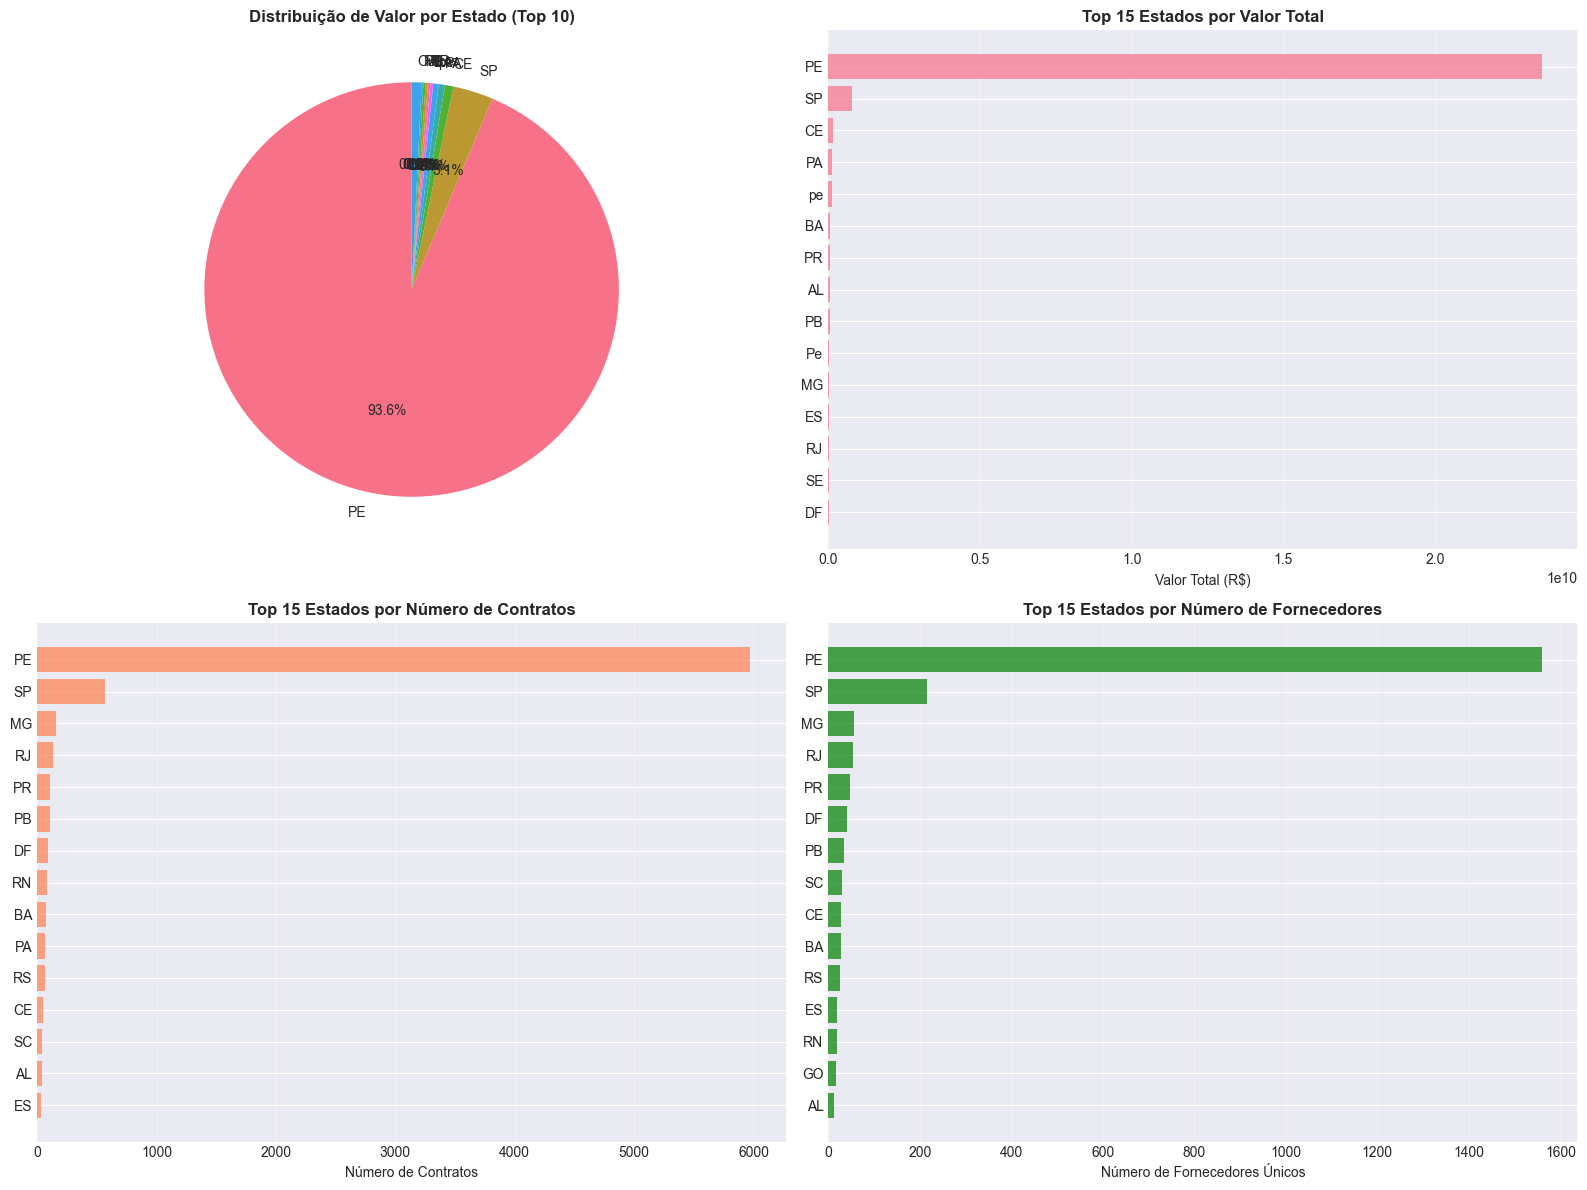

In [39]:
# Análise geográfica por estado
state_analysis = df.groupby('estadoendcontratado').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean'],
    'razaonomecontratado': 'nunique'
}).round(2)
state_analysis.columns = ['num_contratos', 'valor_total', 'valor_medio', 'num_fornecedores']
state_analysis = state_analysis.sort_values('valor_total', ascending=False)

print("DISTRIBUIÇÃO GEOGRÁFICA POR ESTADO")
print("=" * 80)
print(f"\nTotal de estados com fornecedores: {state_analysis.index.notna().sum()}")
display(state_analysis.head(20))

# Calcular percentuais
total_value = state_analysis['valor_total'].sum()
state_analysis['percentual_valor'] = (state_analysis['valor_total'] / total_value * 100).round(2)

print(f"\nConcentração regional:")
print(f"  - Pernambuco (PE): {state_analysis.loc['PE', 'percentual_valor']:.2f}% do valor total")
print(f"  - Top 5 estados: {state_analysis.head(5)['percentual_valor'].sum():.2f}% do valor total")

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico de pizza - Top 10 estados
top_10_states = state_analysis.head(10)
outros_value = state_analysis.iloc[10:]['valor_total'].sum()
pie_data = list(top_10_states['valor_total']) + [outros_value]
pie_labels = list(top_10_states.index) + ['Outros']

axes[0, 0].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribuição de Valor por Estado (Top 10)', fontweight='bold')

# Gráfico de barras - Top 15 estados por valor
top_15_states = state_analysis.head(15)
axes[0, 1].barh(range(len(top_15_states)), top_15_states['valor_total'], alpha=0.7)
axes[0, 1].set_yticks(range(len(top_15_states)))
axes[0, 1].set_yticklabels(top_15_states.index)
axes[0, 1].set_xlabel('Valor Total (R$)')
axes[0, 1].set_title('Top 15 Estados por Valor Total', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# Gráfico de barras - Top 15 estados por número de contratos
top_15_states_qty = state_analysis.sort_values('num_contratos', ascending=False).head(15)
axes[1, 0].barh(range(len(top_15_states_qty)), top_15_states_qty['num_contratos'], 
                alpha=0.7, color='coral')
axes[1, 0].set_yticks(range(len(top_15_states_qty)))
axes[1, 0].set_yticklabels(top_15_states_qty.index)
axes[1, 0].set_xlabel('Número de Contratos')
axes[1, 0].set_title('Top 15 Estados por Número de Contratos', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Gráfico de barras - Top 15 estados por número de fornecedores
top_15_states_suppliers = state_analysis.sort_values('num_fornecedores', ascending=False).head(15)
axes[1, 1].barh(range(len(top_15_states_suppliers)), top_15_states_suppliers['num_fornecedores'], 
                alpha=0.7, color='green')
axes[1, 1].set_yticks(range(len(top_15_states_suppliers)))
axes[1, 1].set_yticklabels(top_15_states_suppliers.index)
axes[1, 1].set_xlabel('Número de Fornecedores Únicos')
axes[1, 1].set_title('Top 15 Estados por Número de Fornecedores', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.2 Análise por Cidade

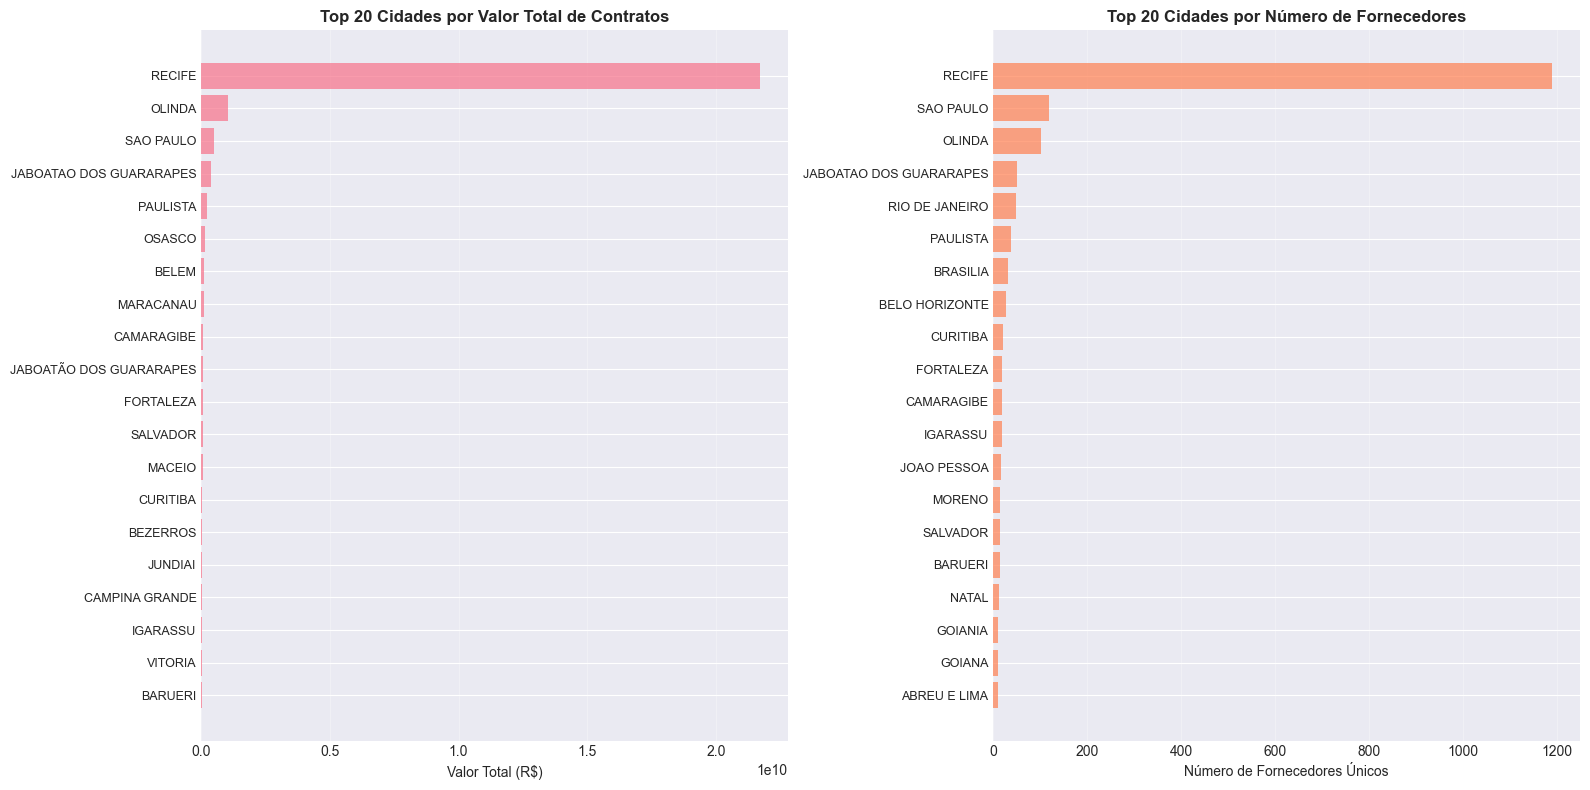

In [40]:
# Análise geográfica por cidade
city_analysis = df.groupby('cidadeendcontratado').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean'],
    'razaonomecontratado': 'nunique'
}).round(2)
city_analysis.columns = ['num_contratos', 'valor_total', 'valor_medio', 'num_fornecedores']
city_analysis = city_analysis.sort_values('valor_total', ascending=False)

print("DISTRIBUIÇÃO GEOGRÁFICA POR CIDADE")
print("=" * 80)
print(f"\nTotal de cidades com fornecedores: {city_analysis.index.notna().sum()}")
print("\nTop 20 cidades:")
display(city_analysis.head(20))

# Calcular percentuais
total_value_city = city_analysis['valor_total'].sum()
city_analysis['percentual_valor'] = (city_analysis['valor_total'] / total_value_city * 100).round(2)

print(f"\nConcentração por cidade:")
print(f"  - Recife: {city_analysis.loc['RECIFE', 'percentual_valor']:.2f}% do valor total")
print(f"  - Top 5 cidades: {city_analysis.head(5)['percentual_valor'].sum():.2f}% do valor total")
print(f"  - Top 10 cidades: {city_analysis.head(10)['percentual_valor'].sum():.2f}% do valor total")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 cidades por valor
top_20_cities = city_analysis.head(20)
axes[0].barh(range(len(top_20_cities)), top_20_cities['valor_total'], alpha=0.7)
axes[0].set_yticks(range(len(top_20_cities)))
axes[0].set_yticklabels(top_20_cities.index, fontsize=9)
axes[0].set_xlabel('Valor Total (R$)')
axes[0].set_title('Top 20 Cidades por Valor Total de Contratos', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Top 20 cidades por número de fornecedores
top_20_cities_suppliers = city_analysis.sort_values('num_fornecedores', ascending=False).head(20)
axes[1].barh(range(len(top_20_cities_suppliers)), top_20_cities_suppliers['num_fornecedores'], 
             alpha=0.7, color='coral')
axes[1].set_yticks(range(len(top_20_cities_suppliers)))
axes[1].set_yticklabels(top_20_cities_suppliers.index, fontsize=9)
axes[1].set_xlabel('Número de Fornecedores Únicos')
axes[1].set_title('Top 20 Cidades por Número de Fornecedores', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.3 Análise de Fornecedores Locais vs Não Locais

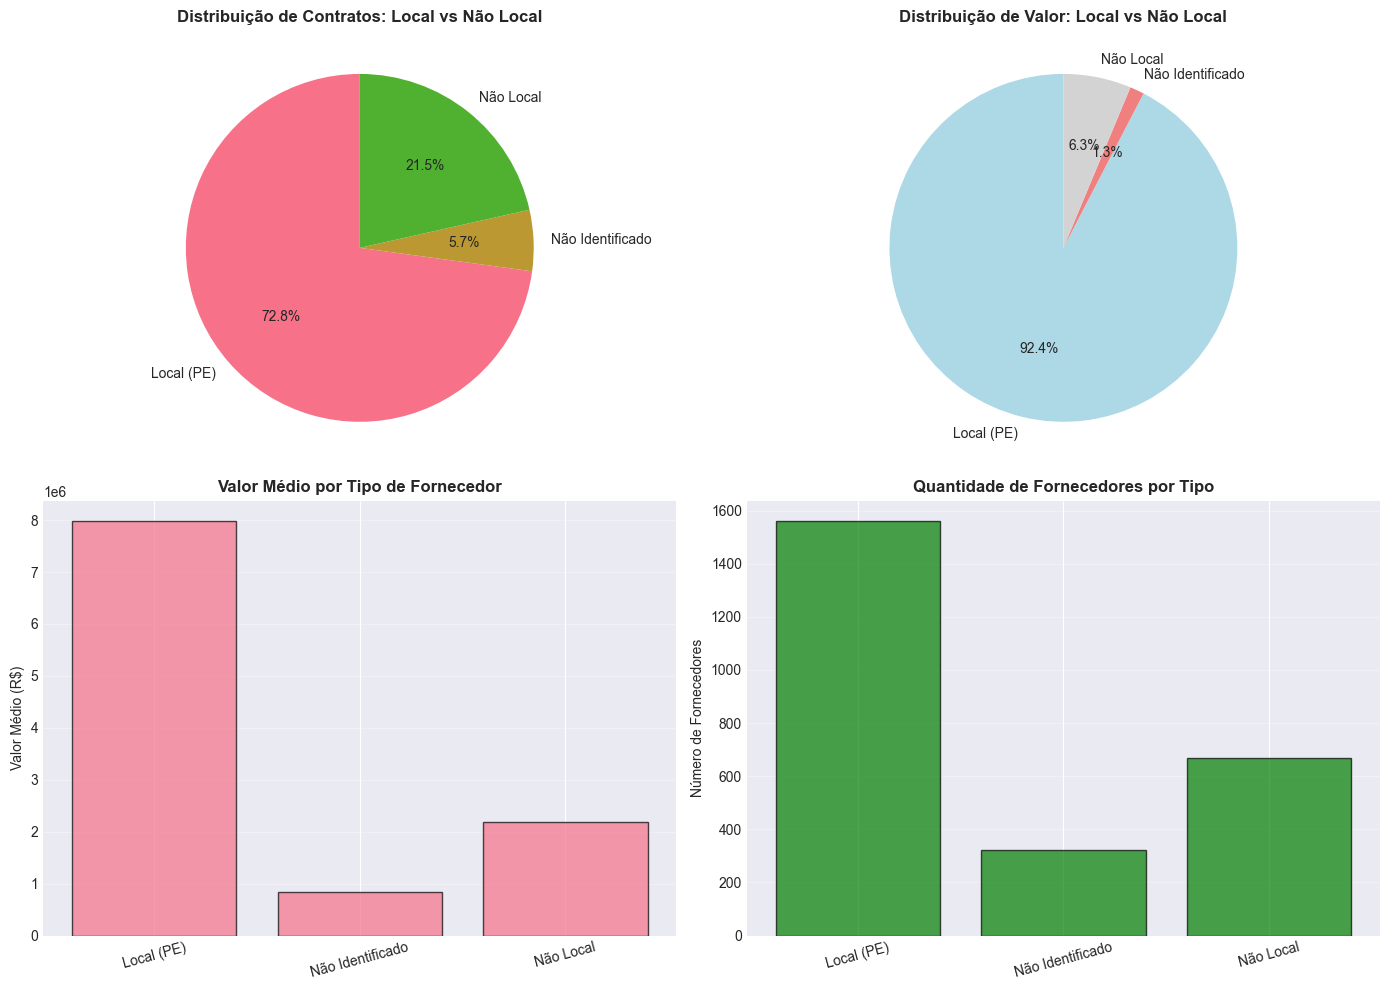

In [41]:
# Classificar fornecedores em locais (PE) e não locais
df['fornecedor_local'] = df['estadoendcontratado'].apply(
    lambda x: 'Local (PE)' if x == 'PE' else ('Não Local' if pd.notna(x) else 'Não Identificado')
)

# Análise comparativa
local_analysis = df.groupby('fornecedor_local').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean', 'median'],
    'razaonomecontratado': 'nunique'
}).round(2)
local_analysis.columns = ['num_contratos', 'valor_total', 'valor_medio', 'valor_mediano', 'num_fornecedores']

print("ANÁLISE: FORNECEDORES LOCAIS VS NÃO LOCAIS")
print("=" * 80)
display(local_analysis)

# Calcular percentuais
total_contracts = local_analysis['num_contratos'].sum()
total_value_local = local_analysis['valor_total'].sum()

print(f"\nConcentração local:")
if 'Local (PE)' in local_analysis.index:
    pct_contracts_local = (local_analysis.loc['Local (PE)', 'num_contratos'] / total_contracts * 100)
    pct_value_local = (local_analysis.loc['Local (PE)', 'valor_total'] / total_value_local * 100)
    print(f"  - Contratos com fornecedores locais: {pct_contracts_local:.2f}%")
    print(f"  - Valor contratado localmente: {pct_value_local:.2f}%")

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pizza - Número de contratos
axes[0, 0].pie(local_analysis['num_contratos'], labels=local_analysis.index, 
               autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribuição de Contratos: Local vs Não Local', fontweight='bold')

# Pizza - Valor total
axes[0, 1].pie(local_analysis['valor_total'], labels=local_analysis.index, 
               autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral', 'lightgray'])
axes[0, 1].set_title('Distribuição de Valor: Local vs Não Local', fontweight='bold')

# Barras - Valor médio
axes[1, 0].bar(local_analysis.index, local_analysis['valor_medio'], alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Valor Médio (R$)')
axes[1, 0].set_title('Valor Médio por Tipo de Fornecedor', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(axis='y', alpha=0.3)

# Barras - Número de fornecedores
axes[1, 1].bar(local_analysis.index, local_analysis['num_fornecedores'], 
               alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_ylabel('Número de Fornecedores')
axes[1, 1].set_title('Quantidade de Fornecedores por Tipo', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

# PARTE 3: ANÁLISE TEXTUAL

## 5. Análise dos Objetos Contratuais

### 5.1 Pré-processamento de Texto

In [42]:
# Função para limpar e normalizar texto
def clean_text(text):
    if pd.isna(text):
        return ''
    # Converter para minúsculas
    text = str(text).lower()
    # Remover acentos
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('ASCII')
    # Remover caracteres especiais e números
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remover espaços múltiplos
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Stopwords em português (básicas)
stopwords_pt = {
    'a', 'o', 'e', 'de', 'da', 'do', 'em', 'para', 'com', 'por', 'na', 'no',
    'ao', 'aos', 'das', 'dos', 'um', 'uma', 'os', 'as', 'que', 'se', 'ou',
    'mais', 'pelo', 'pela', 'pelos', 'pelas', 'ser', 'foi', 'como', 'sobre',
    'apos', 'ate', 'conforme', 'durante', 'entre', 'sob', 'sem', 'atraves',
    'mediante', 'nos', 'nas', 'num', 'numa', 'neste', 'nesta', 'nesse', 'nessa',
    'deste', 'desta', 'desse', 'dessa', 'aquele', 'aquela', 'este', 'esta',
    'esse', 'essa', 'anexo', 'edital', 'termo', 'referencia', 'lote', 'item', 'contratacao',
    'recife', 'municipal'
}

# Processar objetos contratuais
df['objeto_limpo'] = df['objetocontrato'].apply(clean_text)

print("PRÉ-PROCESSAMENTO DE TEXTO CONCLUÍDO")
print("=" * 80)
print(f"\nTotal de contratos com objeto: {df['objeto_limpo'].str.len().gt(0).sum():,}")
print(f"\nExemplos de objetos limpos:")
for i, obj in enumerate(df['objeto_limpo'].head(5), 1):
    print(f"\n{i}. {obj[:150]}...")

PRÉ-PROCESSAMENTO DE TEXTO CONCLUÍDO

Total de contratos com objeto: 8,199

Exemplos de objetos limpos:

1. locacao do imovel nao residencial localizado na rua gervasio pires n no bairro de santo amaro onde esta instalada a sede do conselho tutelar de rpa...

2. a locacao do imovel nao residencial localizado na rua rita antonio felix no no bairro de nova descoberta recife pe para funcionamento do anexo da esco...

3. lotacao de imovel nao residencial situado na rua monte celeste no no bairro brejo da guabiraba recife pe para fixar a sede da estacao regional nordest...

4. locacao de imovel nao residencial situado na rua monte celeste lote no loteamento jardim valparaiso brejo da guabiraba recife pe...

5. servico de gerenciamento do abastecimento de combustiveis de gestao de frota com a aquisicao de combustiveis atraves da tecnologia de cartao eletronic...


### 5.2 Análise de Frequência de Palavras

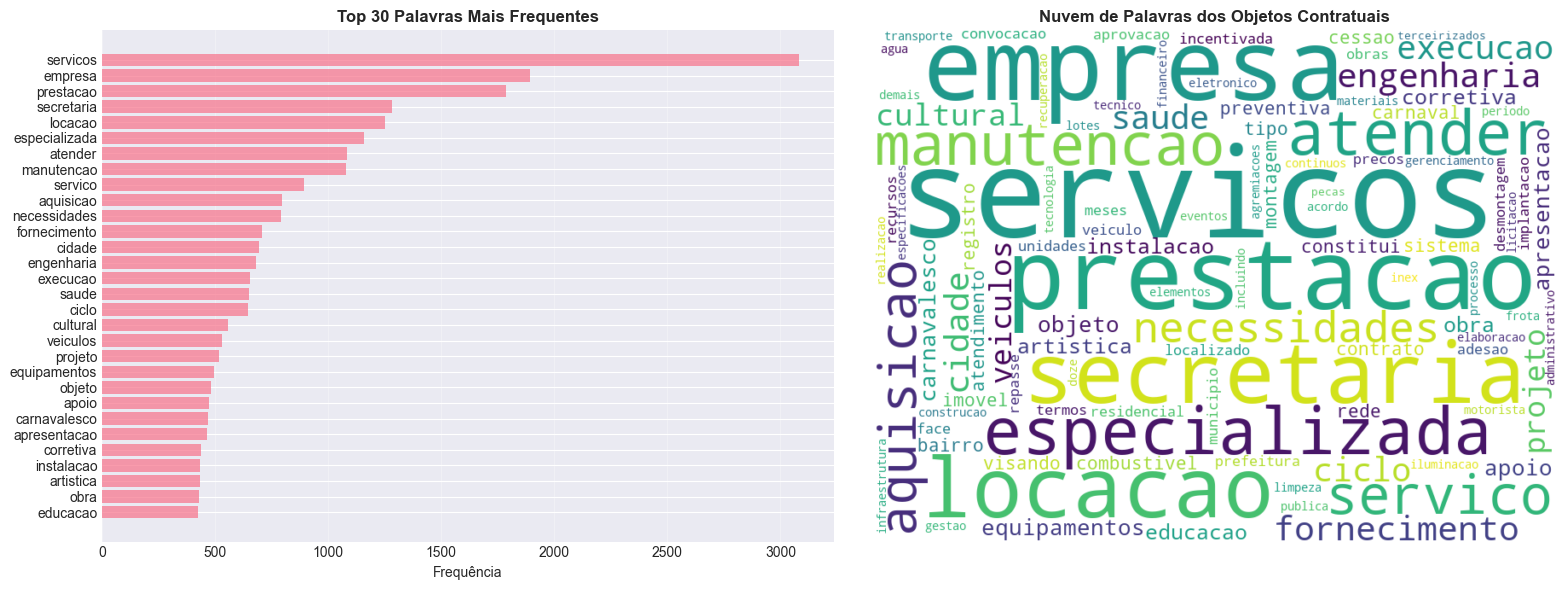

In [43]:
# Extrair todas as palavras
all_words = []
for text in df['objeto_limpo']:
    words = text.split()
    # Filtrar stopwords e palavras muito curtas
    words = [w for w in words if w not in stopwords_pt and len(w) > 3]
    all_words.extend(words)

# Contar frequências
word_freq = Counter(all_words)
top_words = word_freq.most_common(50)

print("ANÁLISE DE FREQUÊNCIA DE PALAVRAS")
print("=" * 80)
print(f"\nTotal de palavras únicas: {len(word_freq):,}")
print(f"Total de palavras (com repetição): {len(all_words):,}")
print(f"\nTop 30 palavras mais frequentes:")

top_30_df = pd.DataFrame(top_words[:30], columns=['Palavra', 'Frequência'])
display(top_30_df)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
words, counts = zip(*top_words[:30])
axes[0].barh(range(len(words)), counts, alpha=0.7)
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].set_xlabel('Frequência')
axes[0].set_title('Top 30 Palavras Mais Frequentes', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Nuvem de palavras
wordcloud = WordCloud(width=800, height=600, background_color='white',
                      max_words=100, colormap='viridis').generate_from_frequencies(word_freq)
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].set_title('Nuvem de Palavras dos Objetos Contratuais', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 5.3 Análise de Bigramas (Pares de Palavras)

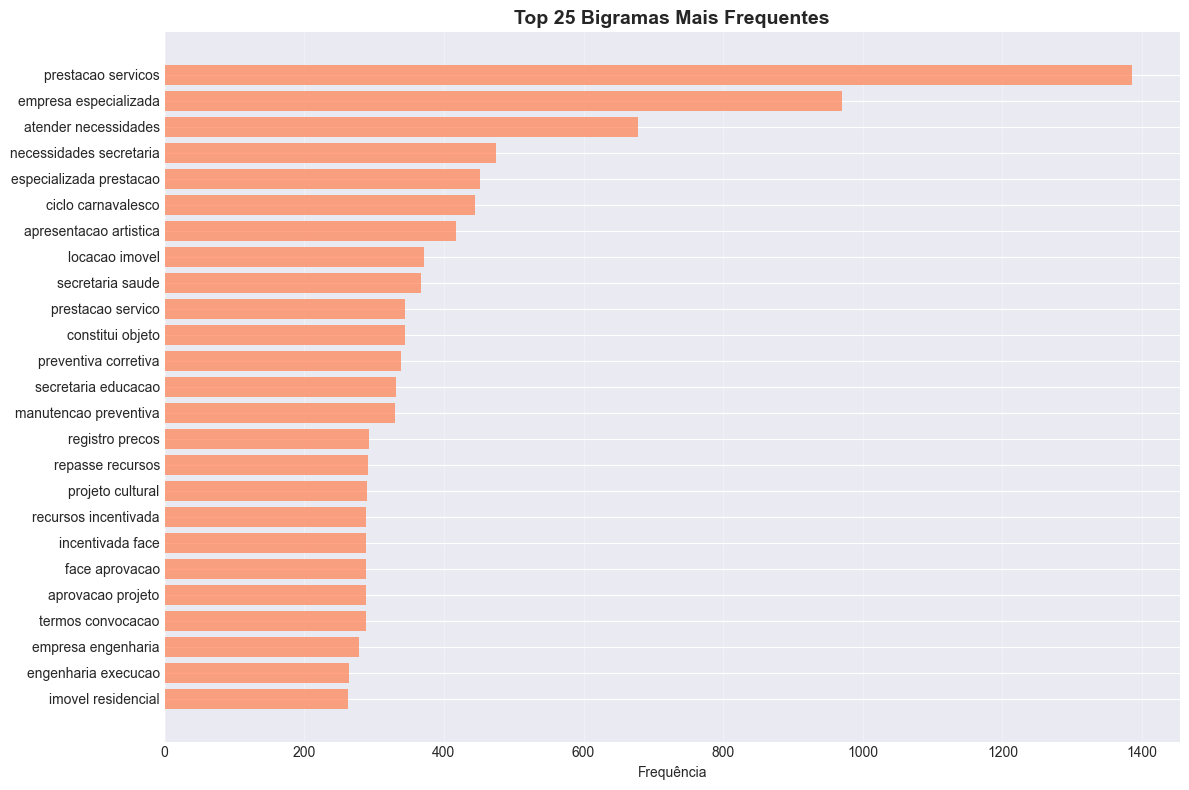

In [44]:
# Extrair bigramas
all_bigrams = []
for text in df['objeto_limpo']:
    words = text.split()
    words = [w for w in words if w not in stopwords_pt and len(w) > 3]
    # Criar bigramas
    bigrams = list(zip(words[:-1], words[1:]))
    all_bigrams.extend(bigrams)

# Contar frequências
bigram_freq = Counter(all_bigrams)
top_bigrams = bigram_freq.most_common(30)

print("ANÁLISE DE BIGRAMAS")
print("=" * 80)
print(f"\nTotal de bigramas únicos: {len(bigram_freq):,}")
print(f"\nTop 30 bigramas mais frequentes:")

bigram_df = pd.DataFrame([
    {' '.join(bigram): count} for bigram, count in top_bigrams
])
bigram_display = pd.DataFrame([
    {'Bigrama': f"{b[0]} {b[1]}", 'Frequência': c} for b, c in top_bigrams
])
display(bigram_display)

# Visualização
fig, ax = plt.subplots(figsize=(12, 8))
bigrams_text, counts = zip(*top_bigrams[:25])
bigrams_labels = [f"{b[0]} {b[1]}" for b in bigrams_text]

ax.barh(range(len(bigrams_labels)), counts, alpha=0.7, color='coral')
ax.set_yticks(range(len(bigrams_labels)))
ax.set_yticklabels(bigrams_labels)
ax.set_xlabel('Frequência')
ax.set_title('Top 25 Bigramas Mais Frequentes', fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 5.4 Categorização Automática de Contratos

Vamos categorizar os contratos com base em palavras-chave presentes nos objetos.

In [45]:
# Definir categorias e palavras-chave
categories = {
    'Infraestrutura e Obras': [
        'obra', 'construcao', 'reforma', 'recuperacao', 'pavimentacao', 'servicos engenharia',
        'drenagem', 'ponte', 'viaduto', 'edificacao', 'instalacao'
    ],
    'Serviços de TI': [
        'software', 'sistema', 'informatica', 'tecnologia', 'dados', 'rede', 'computador',
        'servidor', 'internet', 'desenvolvimento'
    ],
    'Saúde': [
        'saude', 'hospital', 'medico', 'enfermagem', 'ambulancia', 'medicamento',
        'clinico', 'atendimento', 'paciente'
    ],
    'Educação': [
        'educacao', 'escola', 'ensino', 'professor', 'aluno', 'pedagogico',
        'didatico', 'escolar'
    ],
    'Limpeza e Manutenção': [
        'limpeza', 'manutencao', 'conservacao', 'jardinagem', 'higienizacao',
        'zeladoria', 'faxina'
    ],
    'Segurança': [
        'seguranca', 'vigilancia', 'monitoramento', 'alarme', 'guardas'
    ],
    'Transporte e Veículos': [
        'transporte', 'veiculo', 'onibus', 'caminhao', 'frota', 'combustivel',
        'locacao veiculos'
    ],
    'Locação de Imóveis': [
        'locacao imovel', 'aluguel', 'locacao nao residencial'
    ],
    'Alimentação': [
        'alimentacao', 'merenda', 'refeicao', 'refeitorio', 'cozinha', 'alimento'
    ],
    'Consultoria e Assessoria': [
        'consultoria', 'assessoria', 'apoio tecnico', 'capacitacao', 'treinamento'
    ]
}

# Função para categorizar
def categorize_contract(text):
    text = str(text).lower()
    matched_categories = []
    
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in text:
                matched_categories.append(category)
                break
    
    if matched_categories:
        return matched_categories[0]  # Retorna primeira categoria encontrada
    return 'Outros'

# Aplicar categorização
df['categoria'] = df['objeto_limpo'].apply(categorize_contract)

# Análise por categoria
category_analysis = df.groupby('categoria').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean']
}).round(2)
category_analysis.columns = ['num_contratos', 'valor_total', 'valor_medio']
category_analysis = category_analysis.sort_values('valor_total', ascending=False)

print("CATEGORIZAÇÃO DE CONTRATOS")
print("=" * 80)
print(f"\nDistribuição por categoria:")
display(category_analysis)

# Calcular percentuais
total_contracts_cat = category_analysis['num_contratos'].sum()
total_value_cat = category_analysis['valor_total'].sum()
category_analysis['pct_contratos'] = (category_analysis['num_contratos'] / total_contracts_cat * 100).round(2)
category_analysis['pct_valor'] = (category_analysis['valor_total'] / total_value_cat * 100).round(2)

print("\nPercentuais:")
display(category_analysis[['num_contratos', 'pct_contratos', 'valor_total', 'pct_valor']])

,num_contratos,pct_contratos,valor_total,pct_valor
categoria,,,,
Serviços de TI,1057,12.89,"16,360,745,472.66",64.29
Infraestrutura e Obras,1667,20.32,"3,010,070,682.59",11.83
Outros,3122,38.06,"2,330,092,847.15",9.16
Limpeza e Manutenção,529,6.45,"2,011,087,593.97",7.90
Transporte e Veículos,746,9.10,"637,691,725.76",2.51
Educação,305,3.72,"433,789,799.40",1.70
Saúde,521,6.35,"406,230,099.32",1.60
Consultoria e Assessoria,135,1.65,"121,584,237.85",0.48
Segurança,76,0.93,"83,384,242.88",0.33


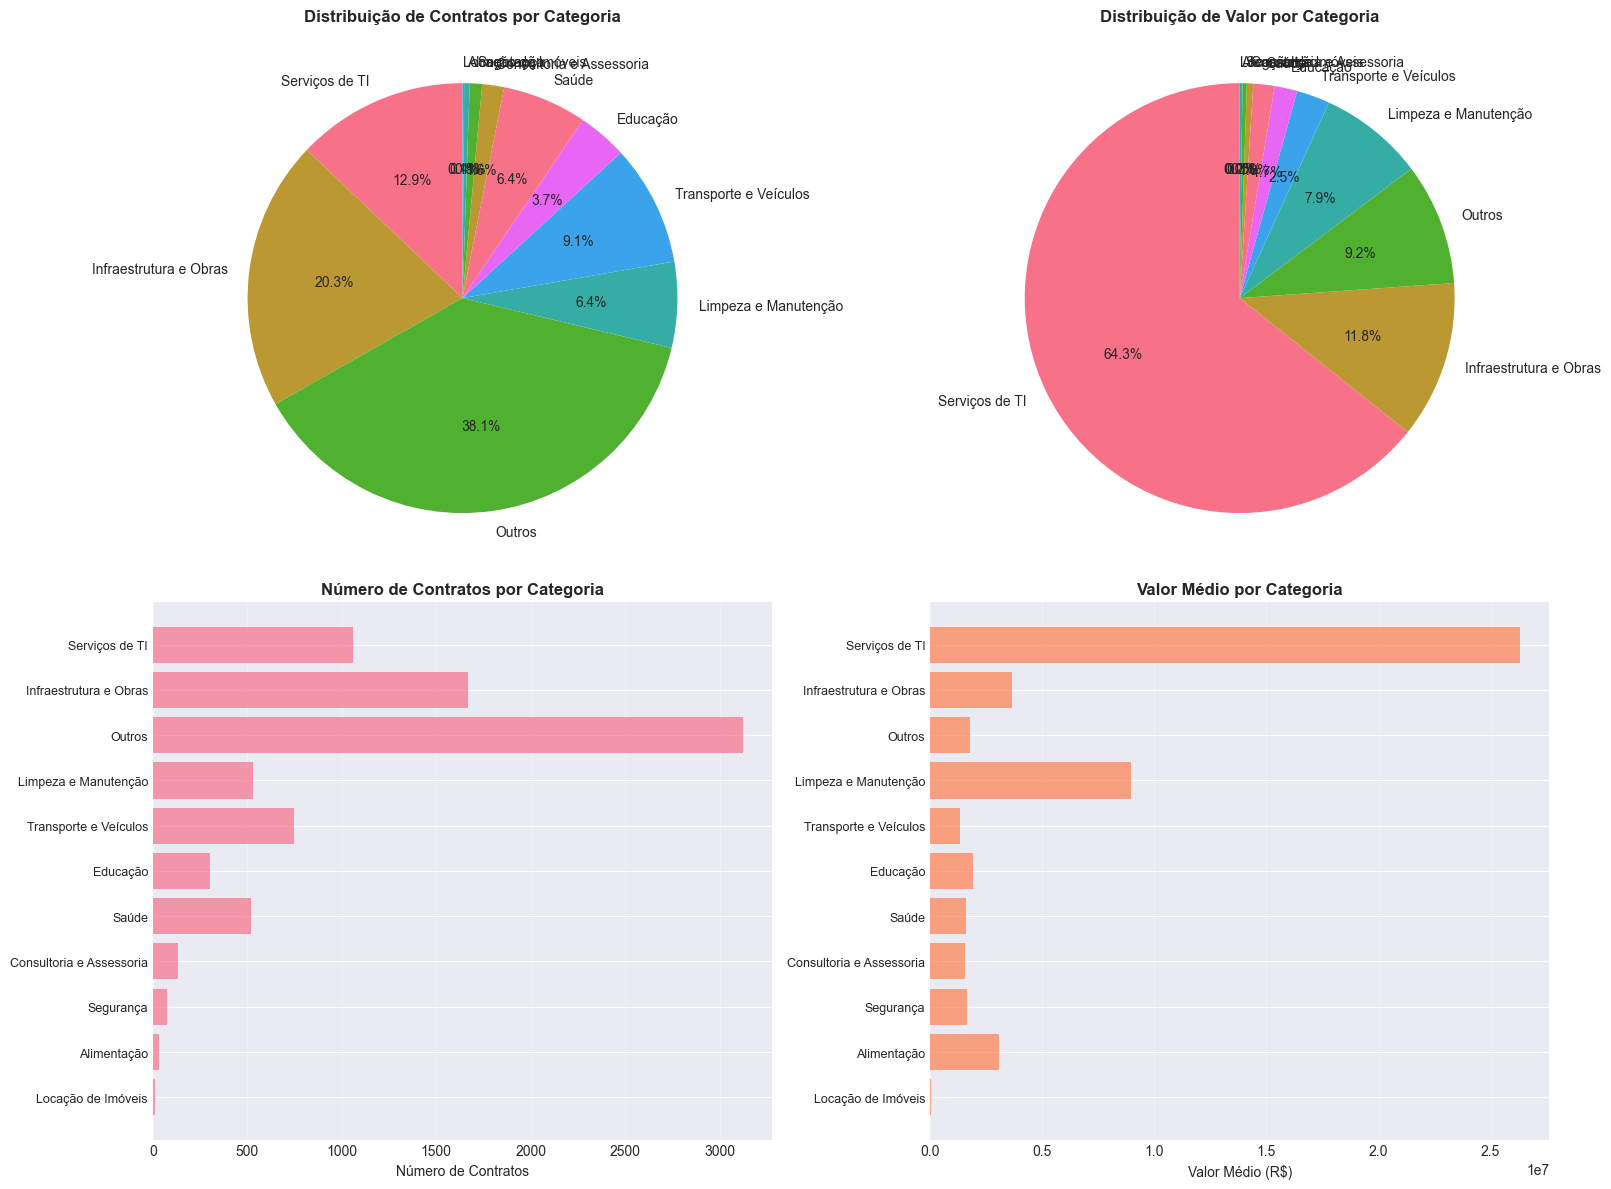

In [46]:
# Visualização de categorias
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Pizza - Número de contratos
axes[0, 0].pie(category_analysis['num_contratos'], labels=category_analysis.index,
               autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribuição de Contratos por Categoria', fontweight='bold')

# Pizza - Valor total
axes[0, 1].pie(category_analysis['valor_total'], labels=category_analysis.index,
               autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Distribuição de Valor por Categoria', fontweight='bold')

# Barras - Número de contratos
axes[1, 0].barh(range(len(category_analysis)), category_analysis['num_contratos'], alpha=0.7)
axes[1, 0].set_yticks(range(len(category_analysis)))
axes[1, 0].set_yticklabels(category_analysis.index, fontsize=9)
axes[1, 0].set_xlabel('Número de Contratos')
axes[1, 0].set_title('Número de Contratos por Categoria', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Barras - Valor médio
axes[1, 1].barh(range(len(category_analysis)), category_analysis['valor_medio'], 
                alpha=0.7, color='coral')
axes[1, 1].set_yticks(range(len(category_analysis)))
axes[1, 1].set_yticklabels(category_analysis.index, fontsize=9)
axes[1, 1].set_xlabel('Valor Médio (R$)')
axes[1, 1].set_title('Valor Médio por Categoria', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### 5.5 Evolução Temporal por Categoria

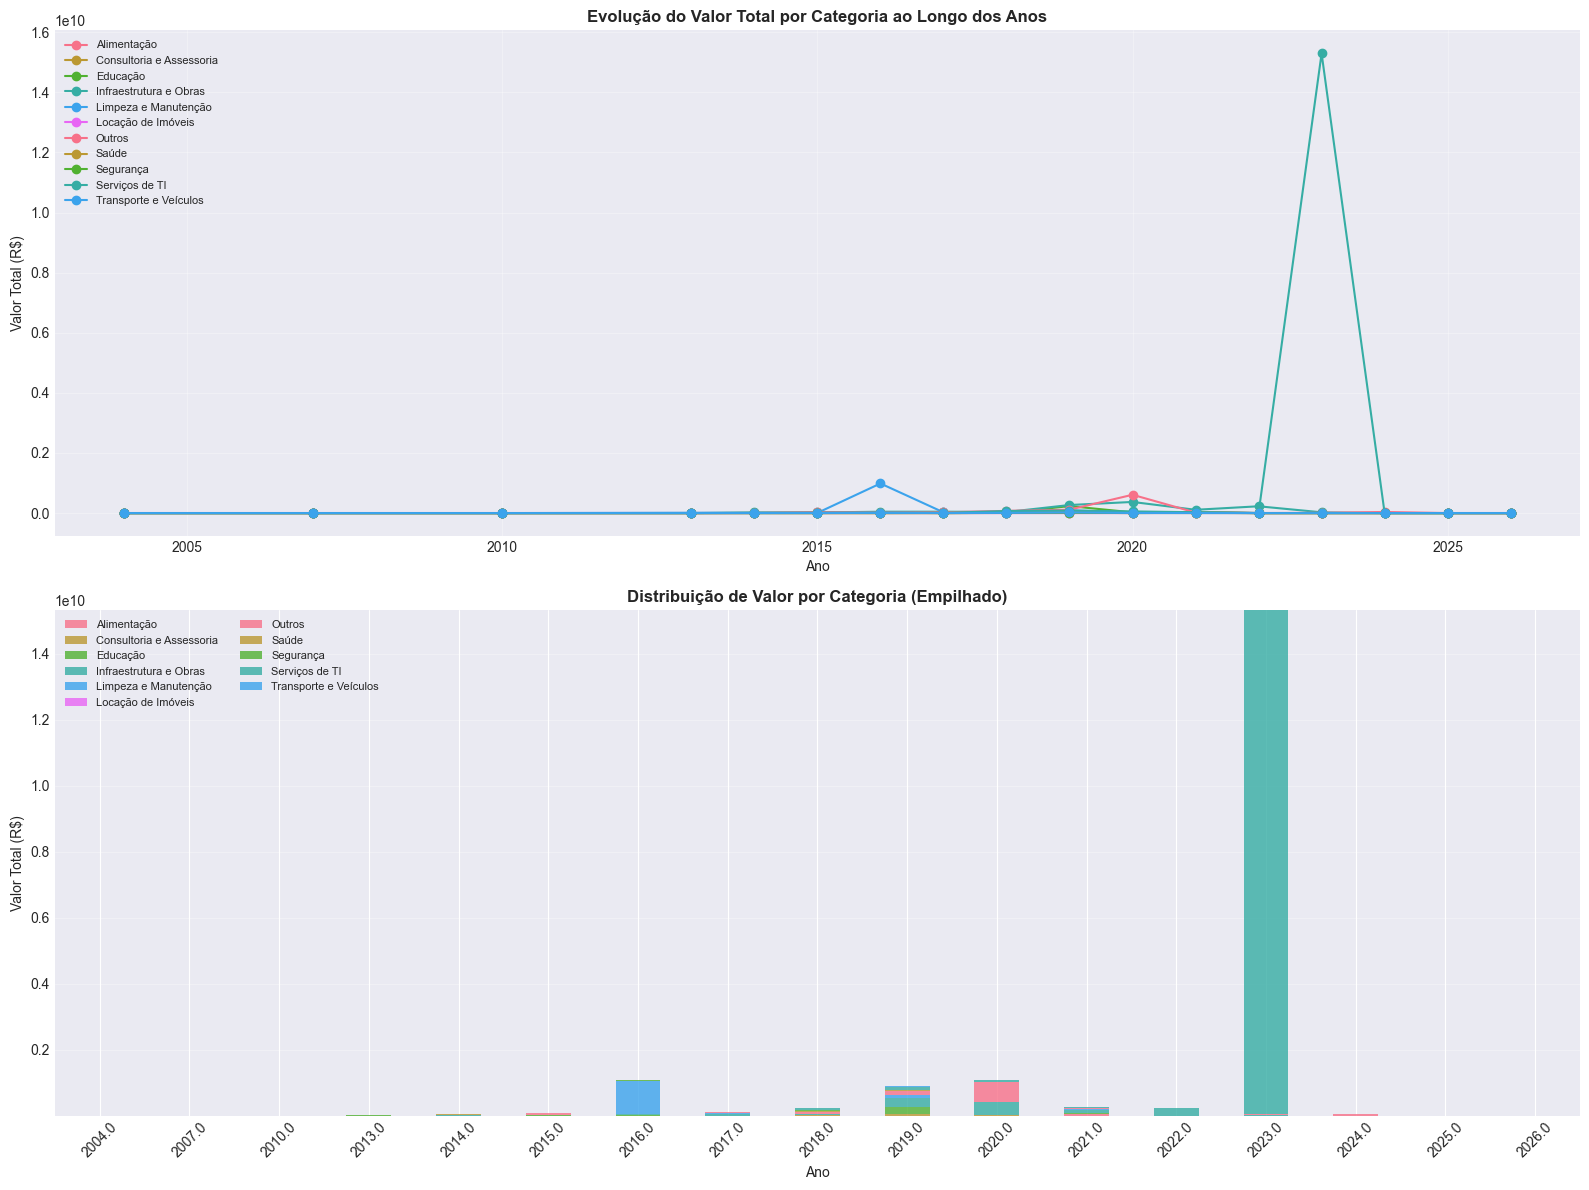

In [47]:
# Análise temporal por categoria
category_year = df.groupby(['anocontrato', 'categoria'])['valorcontrato1'].sum().unstack(fill_value=0)

# Visualização
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Gráfico de linhas - Evolução temporal
for category in category_year.columns:
    axes[0].plot(category_year.index, category_year[category], marker='o', label=category)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Valor Total (R$)')
axes[0].set_title('Evolução do Valor Total por Categoria ao Longo dos Anos', 
                  fontweight='bold', fontsize=12)
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3)

# Gráfico de barras empilhadas
category_year.plot(kind='bar', stacked=True, ax=axes[1], alpha=0.8)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Valor Total (R$)')
axes[1].set_title('Distribuição de Valor por Categoria (Empilhado)', 
                  fontweight='bold', fontsize=12)
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Insights e Conclusões Finais

In [48]:
print("PRINCIPAIS INSIGHTS - ANÁLISE INTERMEDIÁRIA")
print("=" * 80)

print("\n1. ANÁLISE DE RELACIONAMENTOS:")
top_diversified = supplier_agencies.head(1)
print(f"   - Fornecedor mais diversificado: {top_diversified.index[0]}")
print(f"     Atende {top_diversified['num_orgaos'].values[0]} órgãos diferentes")
print(f"   - Densidade da rede: {nx.density(G):.4f} (indica nível de conectividade)")

print("\n2. ANÁLISE GEOGRÁFICA:")
if 'Local (PE)' in local_analysis.index:
    pct_local = (local_analysis.loc['Local (PE)', 'valor_total'] / local_analysis['valor_total'].sum() * 100)
    print(f"   - Contratos com fornecedores locais (PE): {pct_local:.2f}% do valor total")
print(f"   - Estados com fornecedores: {state_analysis.index.notna().sum()}")
print(f"   - Cidades com fornecedores: {city_analysis.index.notna().sum()}")

print("\n3. ANÁLISE TEXTUAL:")
print(f"   - Palavras únicas identificadas: {len(word_freq):,}")
print(f"   - Categorias identificadas: {len(category_analysis)}")
top_category = category_analysis.iloc[0]
print(f"   - Categoria com maior valor: {category_analysis.index[0]}")
print(f"     Valor: R$ {top_category['valor_total']:,.2f} ({top_category['pct_valor']:.1f}% do total)")

print("\n4. INSIGHTS ESTRATÉGICOS:")
multi_agency_suppliers = (supplier_agencies['num_orgaos'] > 5).sum()
print(f"   - {multi_agency_suppliers} fornecedores atendem mais de 5 órgãos diferentes")
print("   - Indica possível especialização ou vantagem competitiva desses fornecedores")

if 'Infraestrutura e Obras' in category_analysis.index:
    infra_value = category_analysis.loc['Infraestrutura e Obras', 'valor_total']
    print(f"   - Infraestrutura e Obras: R$ {infra_value:,.2f}")
    print("   - Categoria típica de alto valor unitário")

print("\n5. RECOMENDAÇÕES:")
print("   - Investigar fornecedores com alta diversificação para entender fatores de sucesso")
print("   - Avaliar políticas de incentivo a fornecedores locais")
print("   - Analisar eficiência comparativa entre categorias de contrato")
print("   - Desenvolver sistema de alertas para concentração excessiva")

PRINCIPAIS INSIGHTS - ANÁLISE INTERMEDIÁRIA

1. ANÁLISE DE RELACIONAMENTOS:
   - Fornecedor mais diversificado: R P L ENGENHARIA E SERVICOS LTDA
     Atende 44 órgãos diferentes
   - Densidade da rede: 0.0949 (indica nível de conectividade)

2. ANÁLISE GEOGRÁFICA:
   - Contratos com fornecedores locais (PE): 92.38% do valor total
   - Estados com fornecedores: 33
   - Cidades com fornecedores: 261

3. ANÁLISE TEXTUAL:
   - Palavras únicas identificadas: 8,640
   - Categorias identificadas: 11
   - Categoria com maior valor: Serviços de TI
     Valor: R$ 16,360,745,472.66 (64.3% do total)

4. INSIGHTS ESTRATÉGICOS:
   - 104 fornecedores atendem mais de 5 órgãos diferentes
   - Indica possível especialização ou vantagem competitiva desses fornecedores
   - Infraestrutura e Obras: R$ 3,010,070,682.59
   - Categoria típica de alto valor unitário

5. RECOMENDAÇÕES:
   - Investigar fornecedores com alta diversificação para entender fatores de sucesso
   - Avaliar políticas de incentivo a for

## 7. Exportação de Resultados

In [49]:
# Salvar dataset enriquecido com categorias
output_path = '../../../data/pe/recife/dados_contratos_categorizado.csv'
df[['numerocontrato', 'anocontrato', 'orgaocontratante', 'razaonomecontratado', 
    'valorcontrato1', 'categoria', 'fornecedor_local']].to_csv(
    output_path, index=False, encoding='utf-8', sep=';'
)
print(f"Dataset categorizado salvo em: {output_path}")

# Salvar análise de categorias
category_output = '../../../data/pe/recife/analise_categorias.csv'
category_analysis.to_csv(category_output, encoding='utf-8', sep=';')
print(f"Análise de categorias salva em: {category_output}")

# Salvar análise geográfica
geo_output = '../../../data/pe/recife/analise_geografica.csv'
state_analysis.to_csv(geo_output, encoding='utf-8', sep=';')
print(f"Análise geográfica salva em: {geo_output}")

print("\nTodos os resultados foram exportados com sucesso!")

Dataset categorizado salvo em: ../../../data/pe/recife/dados_contratos_categorizado.csv
Análise de categorias salva em: ../../../data/pe/recife/analise_categorias.csv
Análise geográfica salva em: ../../../data/pe/recife/analise_geografica.csv

Todos os resultados foram exportados com sucesso!


---

## Conclusão

Esta análise intermediária expandiu significativamente o entendimento dos contratos públicos de Recife através de:

### Análise de Relacionamentos
- Mapeamento de rede bipartida entre fornecedores e órgãos
- Identificação de fornecedores diversificados e centrais
- Análise de similaridade e clustering

### Análise Geográfica
- Distribuição espacial dos fornecedores
- Concentração regional e local
- Comparação entre fornecedores locais e não locais

### Análise Textual
- Extração de palavras-chave e padrões temáticos
- Categorização automática de contratos
- Evolução temporal por categoria

Estes insights fornecem uma base sólida para:
- Políticas de compras mais estratégicas
- Identificação de oportunidades de otimização
- Monitoramento de concentração de mercado
- Desenvolvimento de indicadores de desempenho